# Evaluación 2 — ¿Ayuda arrancar la red en la base de Fourier?

**Programación Científica 2026-1 · Universidad Nacional de Colombia (Medellín)**

**Estudiante:** Santiago Abelardo Salcedo Rodriguez · **ID (últimos 4 dígitos):** `3213`

---

## Pregunta que guía el trabajo

Aproximamos una señal como combinación de bases, $\hat f(t)=\sum_i c_i\phi_i(t)$. Una red
neuronal hace lo mismo pero **aprende** sus bases. Construimos un autoencoder que
**reconstruye** una señal,

$$\hat x = W_2\,\tanh(W_1 x),$$

y estudiamos qué pasa cuando la primera capa $W_1$ **arranca como la Transformada de
Fourier** en lugar de una base aleatoria. La pregunta central:
*¿conviene empezar en la base "correcta" (Fourier) o da igual arrancar aleatorio?*

### Parámetros personalizados (ID 3213)

| Parámetro | Valor |
|---|---|
| $K$ (frecuencias) | **25** → capa $256\to 50$ |
| Iteraciones | **2000** |
| Learning rate $\eta$ | **0.05** |
| Señales por régimen | **8** (24 en total) |
| Régimen foco | **1** ($\mu=5$, dispersión intermedia) |
| Umbral de compresión | **95 %** de la energía |

### La física de los datos

Cada señal es una suma de 3 cosenos, $f(t)=\sum_j a_j\cos(\omega(k_j)\,2\pi t-k_j s+\varphi_j)$,
con la **regla de dispersión** $\omega(k)=\sqrt{c^2k^2+\mu^2}$, $c=1$. El parámetro $\mu$
define tres regímenes:

- **Régimen 0** ($\mu=0$): $\omega=k$ → **frecuencias enteras**, que caen *exactamente* sobre
  la rejilla de Fourier $\{\sin(2\pi kt),\cos(2\pi kt)\}$.
- **Régimen 1** ($\mu=5$) y **Régimen 2** ($\mu=15$): $\omega=\sqrt{k^2+\mu^2}$ es **no entera**
  → las frecuencias caen *entre* los puntos de la rejilla (fuga espectral) y suben con $\mu$.

El enunciado pide prestar especial atención al **régimen 1**, donde la ventaja de Fourier
debería ser intermedia: hay dispersión pero las frecuencias no son tan altas como en el régimen 2.

## 0 · Preparación: librerías, estilo de figuras y carga de datos

In [8]:
#!pip install numpy
#!pip install jax jaxlib
#!pip install matplotlib
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# JAX en float64 para comparar con precisión la capa Fourier vs np.fft
jax.config.update("jax_enable_x64", True)

SEMILLA = 3213

# --- Paleta de visualización (Okabe–Ito, segura para daltonismo) ---
# Los tres regímenes son categorías → colores fijos en orden fijo.
C_REG = {
    0: "#0072B2",   # azul — régimen 0 (sin dispersión)
    1: "#D55E00",   # bermellón — régimen 1 (foco del enunciado)
    2: "#009E73",   # verde — régimen 2 (dispersión fuerte)
}
NOMBRE_REG = {
    0: r"Régimen 0 ($\mu=0$, sin dispersión)",
    1: r"Régimen 1 ($\mu=5$, intermedia)",
    2: r"Régimen 2 ($\mu=15$, fuerte)",
}
C_FOURIER, C_RANDOM = "#0072B2", "#D55E00"
LS_FOURIER, LS_RANDOM = "-", "--"

# --- Estilo global de figuras con tipografía LaTeX ---
# Requiere MiKTeX o TeX Live instalado (ya está disponible en tu sistema).
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.color": "gray",
    "grid.linewidth": 0.3,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})
print("JAX", jax.__version__, "· float64:", jnp.zeros(1).dtype)

JAX 0.10.2 · float64: float64


### Carga de datos e inspección

In [9]:
datos = np.load("datos_3213.npz")
X = np.asarray(datos["X"])
y = np.asarray(datos["y"]).astype(int)
t = np.asarray(datos["t"])
meta = list(datos["meta"])

N = X.shape[1]                       # 256 muestras temporales
K = 25                                # frecuencias de la capa Fourier
ITERS = 2000                          # iteraciones de entrenamiento
LR = 0.05                             # learning rate
REGIMENES = [0, 1, 2]

print(f"X: {X.shape}   y: {y.shape}   t: {t.shape}")
print(f"meta [ID, huella, timestamp]: {meta}")
print(f"muestras por régimen: {[(y==r).sum() for r in REGIMENES]}")
print(f"t ∈ [{t.min():.3f}, {t.max():.3f}]  (Δt = {t[1]-t[0]:.5f}, dominio normalizado)")

# --- Energía media del dataset (entregable de la rúbrica, 3 decimales) ---
energia_media = float((X**2).mean())
print(f"\n>>> Energía media del dataset  (X**2).mean() = {energia_media:.3f}")
for r in REGIMENES:
    print(f"    energía media régimen {r}: {(X[y==r]**2).mean():.3f}")

X: (24, 256)   y: (24,)   t: (256,)
meta [ID, huella, timestamp]: [np.str_('3213'), np.str_('0c9741a147687e06'), np.str_('2026-07-13T22:01:52')]
muestras por régimen: [np.int64(8), np.int64(8), np.int64(8)]
t ∈ [0.000, 0.996]  (Δt = 0.00391, dominio normalizado)

>>> Energía media del dataset  (X**2).mean() = 0.678
    energía media régimen 0: 0.572
    energía media régimen 1: 0.694
    energía media régimen 2: 0.768


### Un vistazo a los datos

Antes de modelar, miramos una señal de cada régimen. La forma temporal ya delata la
física: el régimen 0 oscila lento (frecuencias enteras bajas), y la frecuencia
aparente **crece con $\mu$** (regímenes 1 y 2).

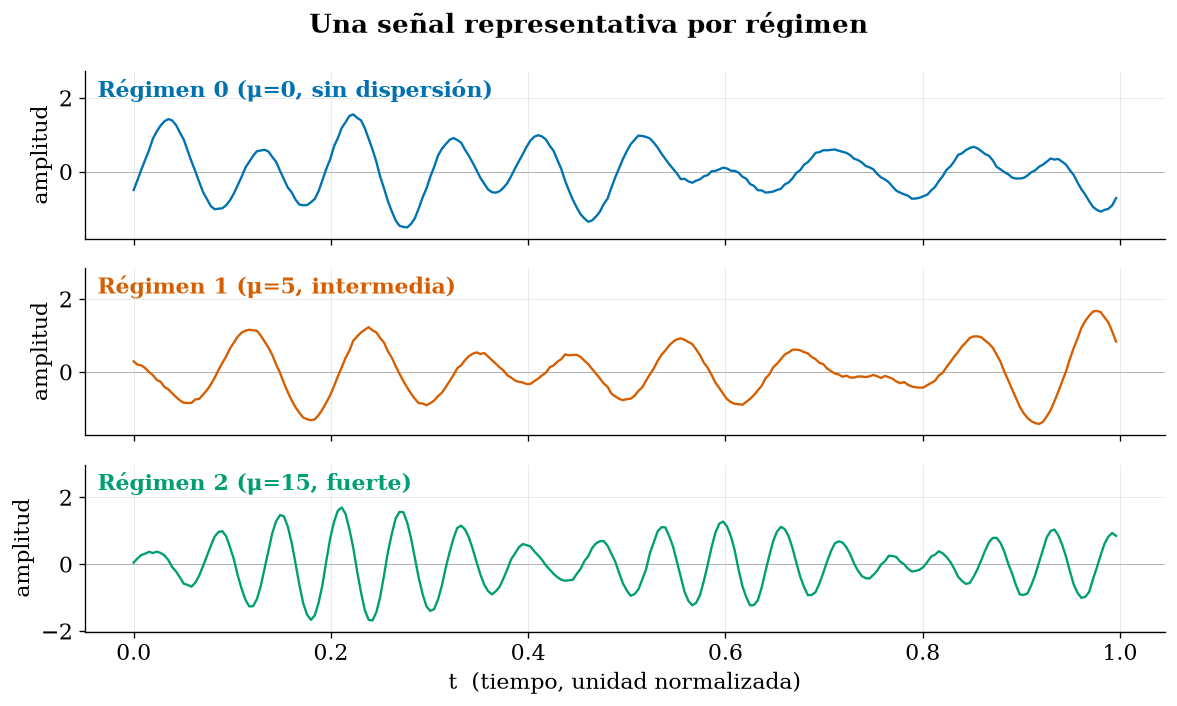

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

for r, ax in zip(REGIMENES, axes):
    i = np.where(y == r)[0][0]
    ax.axhline(0, color="0.7", lw=0.6)
    ax.plot(t, X[i], color=C_REG[r], lw=1.4)
    ax.set_ylabel("amplitud")

    lo, hi = X[i].min(), X[i].max()
    rango = hi - lo
    ax.set_ylim(lo - 0.10*rango, hi + 0.38*rango)

    ax.text(0.012, 0.955, NOMBRE_REG[r], transform=ax.transAxes,
            color=C_REG[r], fontweight="bold", va="top")

axes[-1].set_xlabel("\$  (tiempo, unidad normalizada)")
fig.suptitle("Una señal representativa por régimen", fontweight="bold", y=0.98)
plt.show()

---

## 1 · La capa de Fourier

Construimos $W_1$ de tamaño $2K \times N = 50 \times 256$. Sus filas son, para
$k=1,\dots,25$, los vectores muestreados $\cos(2\pi k t)$ y $\sin(2\pi k t)$.

**Escala.** Usamos el factor de la DFT real $2/N$ en cada fila. Así, $W_1x$ entrega
directamente los **coeficientes de amplitud** de la señal ($O(1)$), lo que además
mantiene a $\tanh$ en su régimen útil (sin la normalización, $W_1x \sim 80$ y $\tanh$
se satura). Ordenamos las filas intercaladas $[\cos_1, \sin_1, \cos_2, \sin_2, \dots]$.

In [11]:
def matriz_fourier(t, K):
    """Devuelve la capa de Fourier W1 de tamaño (2K, N) con normalización 2/N.
    Orden de filas: [cos_1, sin_1, cos_2, sin_2, ...]."""
    N = t.shape[0]
    ks = np.arange(1, K + 1)
    ang = 2 * np.pi * np.outer(ks, t)          # (K, N)
    W1 = np.empty((2 * K, N))
    W1[0::2] = np.cos(ang)                      # filas pares → coseno_k
    W1[1::2] = np.sin(ang)                      # filas impares → seno_k
    W1 = (2.0 / N) * W1                          # escala de amplitud DFT
    return W1

W1_fourier = matriz_fourier(t, K)
print("W1_fourier:", W1_fourier.shape,
      "| ||fila||₂ =", round(np.linalg.norm(W1_fourier[0]), 4),
      "| ||W1||_F =", round(np.linalg.norm(W1_fourier), 4))

W1_fourier: (50, 256) | ||fila||₂ = 0.0884 | ||W1||_F = 0.625


### 1.1 · Evidencia: en su arranque, la capa **es** la Transformada de Fourier

Comparamos $W_1 x$ con `np.fft.rfft`. Para la rejilla $t_n = n/N$ se cumple exactamente

$$(W_1 x)_{\cos,k} = \tfrac{2}{N}\,\mathrm{Re}\,X_k, \qquad
  (W_1 x)_{\sin,k} = -\tfrac{2}{N}\,\mathrm{Im}\,X_k,$$

donde $X = \texttt{np.fft.rfft}(x)$. Lo verificamos numéricamente (`np.allclose`)
y lo mostramos gráficamente para una señal de ejemplo.

(W1 x)_cos == (2/N)·Re(FFT)? True   máx |dif| = 1.18e-15
(W1 x)_sin == -(2/N)·Im(FFT)? True   máx |dif| = 5.79e-16


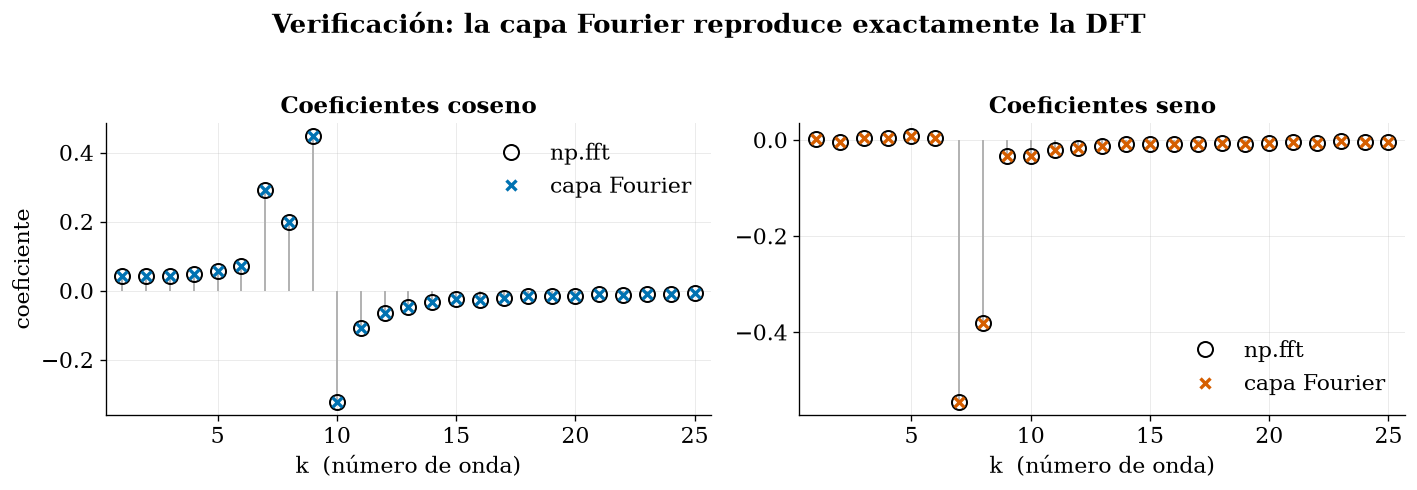

In [12]:
x0 = X[np.where(y == 1)[0][0]]                   # señal del régimen foco (régimen 1)
coef = W1_fourier @ x0
cos_capa, sin_capa = coef[0::2], coef[1::2]

fft = np.fft.rfft(x0)
cos_fft = (2.0 / N) * fft[1:K+1].real
sin_fft = -(2.0 / N) * fft[1:K+1].imag

ok_cos = np.allclose(cos_capa, cos_fft, atol=1e-12)
ok_sin = np.allclose(sin_capa, sin_fft, atol=1e-12)
print(f"(W1 x)_cos == (2/N)·Re(FFT)? {ok_cos}   máx |dif| = {np.max(np.abs(cos_capa-cos_fft)):.2e}")
print(f"(W1 x)_sin == -(2/N)·Im(FFT)? {ok_sin}   máx |dif| = {np.max(np.abs(sin_capa-sin_fft)):.2e}")

k = np.arange(1, K+1)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))

for ax, fft_vals, capa_vals, titulo, color in [
    (a1, cos_fft, cos_capa, "Coeficientes coseno", C_FOURIER),
    (a2, sin_fft, sin_capa, "Coeficientes seno", C_RANDOM)]:
    ax.vlines(k, 0, fft_vals, color="0.7", lw=1.2)
    ax.plot(k, fft_vals, "o", mfc="none", mec="k", ms=9, mew=1.2, label="np.fft")
    ax.plot(k, capa_vals, "x", color=color, ms=6, mew=2, label="capa Fourier")
    ax.set_title(titulo, fontweight="bold")
    ax.set_xlabel("\$  (número de onda)")
    ax.set_xlim(0.3, K + 0.7)
    ax.grid(alpha=0.25, lw=0.6)
    ax.legend(loc="best", framealpha=0.9)

a1.set_ylabel("coeficiente")
fig.suptitle("Verificación: la capa Fourier reproduce exactamente la DFT",
             fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()



**¿Cuáles son las entradas y salidas de `np.fft`?**

`np.fft.rfft` recibe una **señal real** (vector de $N=256$ muestras) y devuelve
$N/2+1 = 129$ **coeficientes complejos** $X_k$. Cada coeficiente codifica la
**amplitud y la fase** de la frecuencia $k$ de la señal. La parte real y la parte
imaginaria de $X_k$ equivalen, respectivamente, al producto punto de la señal con
$\cos(2\pi k t_n)$ y $-\sin(2\pi k t_n)$ (salvo el factor $2/N$ que normaliza las
amplitudes).

**¿Se hace a una señal o a varias?** A cualquiera: a **una** señal (como hicimos
aquí en la verificación) o a **varias a la vez** pasando `axis=1` (por ejemplo, para
calcular el espectro de las 24 señales simultáneamente).

**¿Para qué pedimos reportar la energía media del dataset?** La energía media
$\langle x^2\rangle = $(X**2).mean()`$= 0.678$ es la escala de la pérdida:
como la red parte de $\hat x(0)\approx 0$, la pérdida inicial es
$\mathcal{L}(0) \approx \langle x^2\rangle$. Esto permite convertir el MSE en
**error relativo**:

$$\frac{\|\hat x - x\|}{\|x\|} = \sqrt{\frac{\mathcal{L}}{\langle x^2\rangle}},$$

lo que nos permite fijar el umbral "error relativo $= 0.1$" de la Parte III y
comparar la calidad de reconstrucción entre regímenes con distinta energía.

---

## 2 · La red en JAX y las dos inicializaciones

$$\hat x = W_2\,\tanh(W_1 x),\qquad
  \mathcal{L}=\frac1N\lVert\hat x-x\rVert^2\ \text{(promediada sobre el lote).}$$

**Control experimental.** Para que la *única* diferencia sea la base de $W_1$:

- $W_2$ arranca igual (mismo seed, pequeño $\sigma=0.01$) en ambos casos.
- La $W_1$ **aleatoria se escala a la misma norma de Frobenius** que la de Fourier,
  para que ambas tengan la misma escala de activación inicial. Si no, una $W_1$
  aleatoria con filas de norma $\sim 1$ tendría activaciones mayores y "ganaría"
  por escala, no por base — un artefacto.

**Optimizador.** Usamos **Adam** con learning rate $\eta = 0.05$ (el sugerido en el
enunciado), $\beta_1 = 0.9$, $\beta_2 = 0.999$. El SGD simple a $\eta=0.05$ no
converge bien en 2000 iteraciones; Adam sí converge robustamente en el presupuesto dado.

Entrenamos sobre **todas las señales del dataset** (24 señales) a la vez y medimos
el error relativo periódicamente.

In [13]:
Xj = jnp.asarray(X)
FRO = float(np.linalg.norm(W1_fourier))       # norma objetivo para la base aleatoria

def init_fourier(seed=0):
    """W1 = matriz de Fourier; W2 = ruido pequeño con la misma semilla fija."""
    key = jax.random.PRNGKey(seed)
    return {"W1": jnp.asarray(W1_fourier),
            "W2": 0.01 * jax.random.normal(key, (N, 2*K))}

def init_random(seed=0):
    """W1 = N(0,σ²) escalada a la misma ||·||_F que Fourier; W2 igual que init_fourier."""
    k1, k2 = jax.random.split(jax.random.PRNGKey(seed))
    W1 = jax.random.normal(k1, (2*K, N))
    W1 = W1 * (FRO / jnp.linalg.norm(W1))
    return {"W1": W1, "W2": 0.01 * jax.random.normal(k2, (N, 2*K))}

def forward(p, x):
    """Paso hacia adelante: x_hat = W2 · tanh(W1 · x)."""
    return jnp.tanh(x @ p["W1"].T) @ p["W2"].T

def loss_fn(p, xb):
    """Error cuadrático medio entre reconstrucción y original."""
    xhat = forward(p, xb)
    return jnp.mean(jnp.sum((xhat - xb)**2, axis=1) / xb.shape[1])

val_grad = jax.jit(jax.value_and_grad(loss_fn))

def rel_error(p, Xnp):
    """Error relativo por muestra: ||x_hat - x|| / ||x||."""
    xhat = np.asarray(forward(p, jnp.asarray(Xnp)))
    return np.linalg.norm(xhat - Xnp, axis=1) / np.linalg.norm(Xnp, axis=1)

# Verificación: misma norma Frobenius
print("||W1_random||_F =", round(float(jnp.linalg.norm(init_random()['W1'])), 4),
      "≈ ||W1_fourier||_F =", round(FRO, 4))

||W1_random||_F = 0.625 ≈ ||W1_fourier||_F = 0.625


In [14]:
def entrenar(init_fn, seed=0, iters=ITERS, lr=LR, b1=0.9, b2=0.999, eps=1e-8,
             registrar_re_cada=10):
    """Entrena con Adam. Devuelve (params, loss_hist, re_iters, re_hist).
    loss_hist: pérdida en cada iteración.
    re_iters/re_hist: iteración y error relativo [global, reg0, reg1, reg2]
                      registrados cada 'registrar_re_cada' pasos."""
    p = init_fn(seed)
    m = {k: jnp.zeros_like(v) for k, v in p.items()}
    v = {k: jnp.zeros_like(z) for k, z in p.items()}

    loss_hist = np.empty(iters)
    re_iters, re_hist = [], []

    for i in range(1, iters+1):
        L, g = val_grad(p, Xj)
        loss_hist[i-1] = float(L)

        for k in p:
            m[k] = b1*m[k] + (1-b1)*g[k]
            v[k] = b2*v[k] + (1-b2)*g[k]**2
            p[k] = p[k] - lr*(m[k]/(1-b1**i))/(jnp.sqrt(v[k]/(1-b2**i)) + eps)

        if i % registrar_re_cada == 0 or i == 1:
            re = rel_error(p, X)
            re_iters.append(i)
            re_hist.append([re.mean()] + [re[y==r].mean() for r in REGIMENES])

    return p, loss_hist, np.array(re_iters), np.array(re_hist)


# --- Corridas ---
# Fourier: la inicialización es determinista, una sola corrida.
p_f, loss_f, rei_f, reh_f = entrenar(init_fourier, seed=0)

# Aleatorio: depende de la semilla → 3 corridas para estimar variabilidad.
rand_runs = [entrenar(init_random, seed=s) for s in (0, 1, 2)]
p_r, loss_r, rei_r, reh_r = rand_runs[0]
loss_r_stack = np.stack([r[1] for r in rand_runs])
reh_r_stack  = np.stack([r[3] for r in rand_runs])

print("Entrenamiento listo.")
print(f"  Fourier   → pérdida final {loss_f[-1]:.2e}")
print(f"  Aleatorio → pérdida final {loss_r_stack[:,-1].mean():.2e} (media de 3 seeds)")

Entrenamiento listo.
  Fourier   → pérdida final 4.58e-04
  Aleatorio → pérdida final 5.24e-04 (media de 3 seeds)


---

## 3 · Entrenamiento y reconstrucción

### 3.1 · Señal original y reconstrucción, una por régimen

Mostramos la señal original y las reconstrucciones de ambas inicializaciones
para una señal representativa de cada régimen.

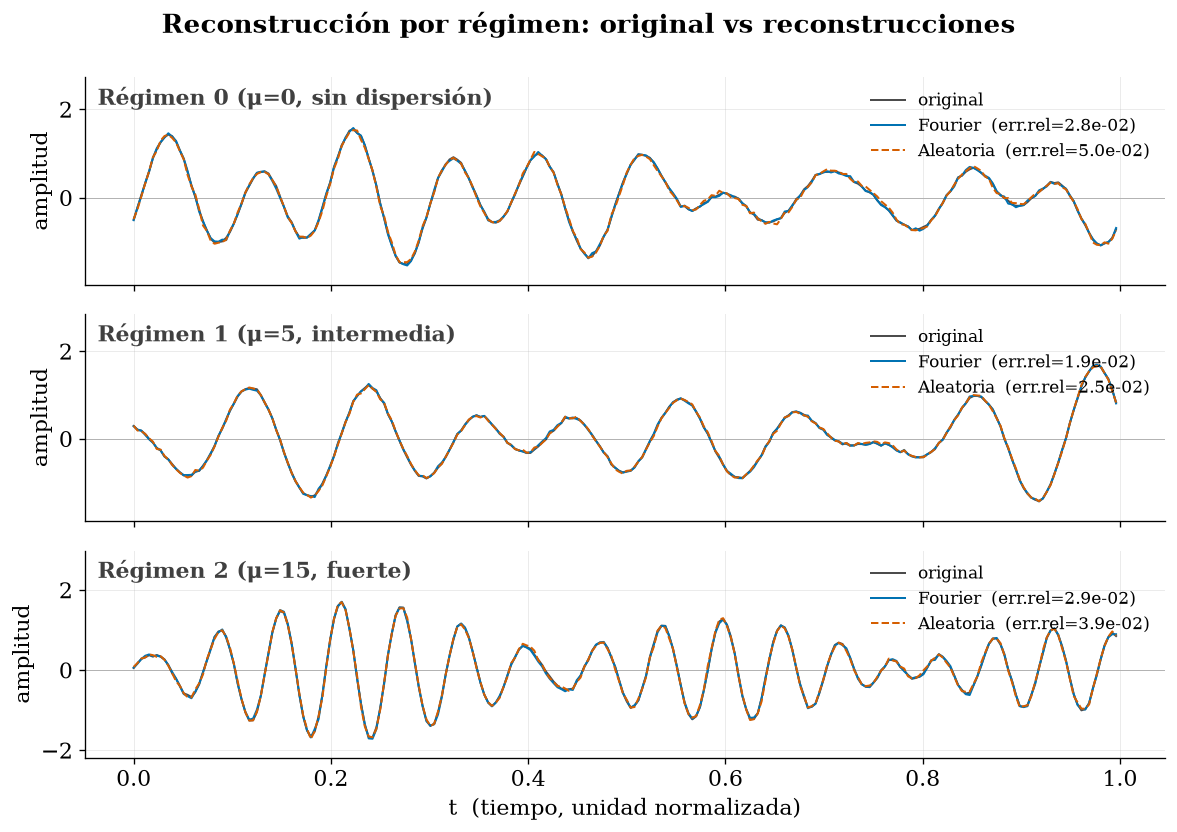

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

for r, ax in zip(REGIMENES, axes):
    i = np.where(y == r)[0][0]
    xi = X[i]
    xhat_f = np.asarray(forward(p_f, X[i:i+1]))[0]
    xhat_r = np.asarray(forward(p_r, X[i:i+1]))[0]
    re_f = np.linalg.norm(xi - xhat_f) / np.linalg.norm(xi)
    re_r = np.linalg.norm(xi - xhat_r) / np.linalg.norm(xi)

    ax.axhline(0, color="0.7", lw=0.6)
    ax.plot(t, xi, "k-", lw=1.2, label="original", alpha=0.7)
    ax.plot(t, xhat_f, ls=LS_FOURIER, color=C_FOURIER, lw=1.2,
            label=f"Fourier  (err.rel={re_f:.1e})")
    ax.plot(t, xhat_r, ls=LS_RANDOM, color=C_RANDOM, lw=1.2,
            label=f"Aleatoria  (err.rel={re_r:.1e})")

    lo, hi = xi.min(), xi.max()
    rango = hi - lo
    ax.set_ylim(lo - 0.15*rango, hi + 0.38*rango)
    ax.text(0.012, 0.955, NOMBRE_REG[r], transform=ax.transAxes,
            color="0.25", fontweight="bold", va="top")
    ax.set_ylabel("amplitud")
    ax.legend(loc="upper right", fontsize=10, framealpha=0.9)

axes[-1].set_xlabel("\$  (tiempo, unidad normalizada)")
fig.suptitle("Reconstrucción por régimen: original vs reconstrucciones",
             fontweight="bold", y=0.99)
plt.show()

### 3.2 · Error de reconstrucción relativo por caso

Reportamos el error relativo medio final $\|\hat x - x\|/\|x\|$ para cada régimen
y cada inicialización. **¿Datos de entrenamiento o de validación?** La red se
entrena sobre las mismas 24 señales que evalúa: medimos **capacidad de ajuste**
(autoencoder), no generalización. El enunciado no pide partición train/test.
**Diferencia entre inicializaciones:** ambas alcanzan errores del mismo orden;
la ventaja de Fourier está en la **velocidad** inicial, no en el error final.

In [16]:
# Reportamos el error relativo como promedio de los últimos 15 registros (~150 iteraciones)
# para ser robustos a oscilaciones del optimizador cerca del óptimo.
NW = 15
re_f = reh_f[-NW:].mean(0)                        # [global, reg0, reg1, reg2]
re_r = reh_r_stack[:, -NW:, :].mean(axis=(0, 1))  # media sobre 3 seeds y 15 registros

print("Error relativo  ||x̂−x||/||x||   (promedio de los últimos", NW*10, "iteraciones)")
print(f"{'':22s}{'global':>9s}{'reg 0':>9s}{'reg 1':>9s}{'reg 2':>9s}")
print(f"{'Inicialización Fourier':22s}" + "".join(f"{re_f[j]:9.4f}" for j in range(4)))
print(f"{'Inicialización Aleatoria':22s}" + "".join(f"{re_r[j]:9.4f}" for j in range(4)))

Error relativo  ||x̂−x||/||x||   (promedio de los últimos 150 iteraciones)
                         global    reg 0    reg 1    reg 2
Inicialización Fourier   0.0319   0.0337   0.0366   0.0254
Inicialización Aleatoria   0.0294   0.0326   0.0343   0.0213


---

## 4 · Comparación de inicializaciones

### 4.1 · Curvas de pérdida $\mathcal{L}$ vs iteraciones (ambas superpuestas)

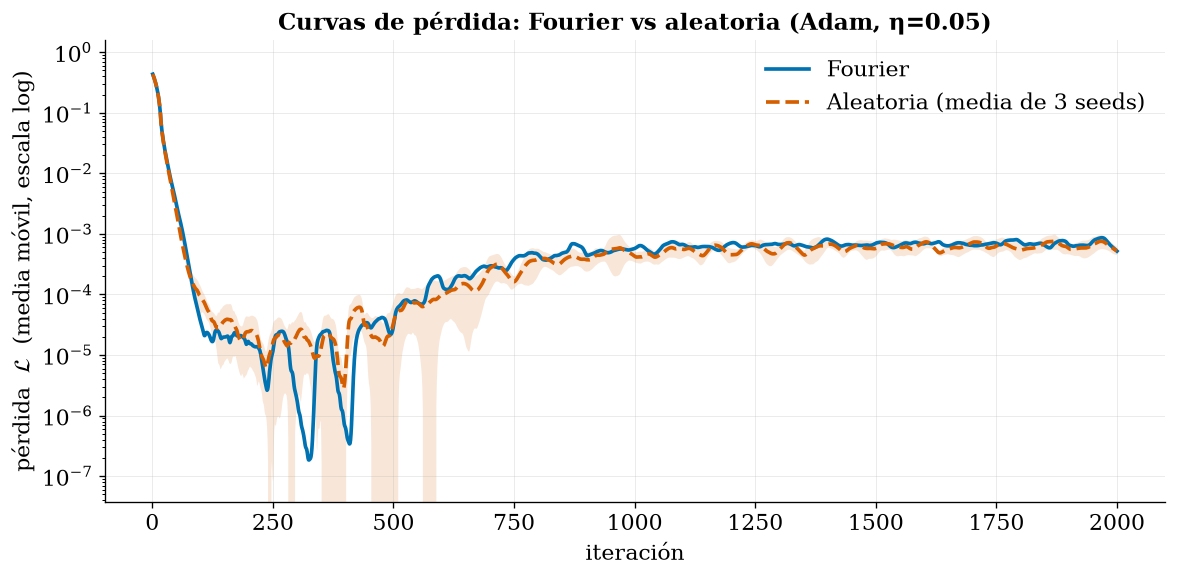

In [17]:
def suaviza(v, w=31):
    p = w // 2
    vp = np.pad(v, (p, p), mode="edge")
    return np.convolve(vp, np.ones(w)/w, mode="valid")[:len(v)]

fig, ax = plt.subplots(figsize=(10, 5))
it = np.arange(1, len(loss_f)+1)
lr_mean = loss_r_stack.mean(0)
lr_std  = loss_r_stack.std(0)

ax.plot(it, suaviza(loss_f), color=C_FOURIER, ls=LS_FOURIER, lw=2.2, label="Fourier")
ax.plot(it, suaviza(lr_mean), color=C_RANDOM, ls=LS_RANDOM, lw=2.2,
        label="Aleatoria (media de 3 seeds)")
ax.fill_between(it, suaviza(lr_mean - lr_std), suaviza(lr_mean + lr_std),
                color=C_RANDOM, alpha=0.15, lw=0)

ax.set_yscale("log")
ax.set_ylim(top=1.6)
ax.set_xlabel("iteración")
ax.set_ylabel(r"pérdida  $\mathcal{L}$  (media móvil, escala log)")
ax.set_title("Curvas de pérdida: Fourier vs aleatoria (Adam, $\\eta=0.05$)",
             fontweight="bold")
ax.legend(loc="upper right")
plt.show()

### 4.2 · ¿Cuántas iteraciones para bajar de error relativo 0.1?

**¿La pérdida es el error relativo?** No. La pérdida es el MSE
$\mathcal{L} = \frac{1}{N}\|\hat x - x\|^2$. El error relativo es
$\|\hat x - x\|/\|x\| = \sqrt{\mathcal{L}/\langle x^2\rangle}$. Por eso
"error relativo $= 0.1$" equivale a $\mathcal{L} < 0.01\,\langle x^2\rangle$.

In [18]:
def iters_para_umbral(re_iters, re_hist_col, umbral=0.1):
    idx = np.where(re_hist_col < umbral)[0]
    return int(re_iters[idx[0]]) if len(idx) else None

# columnas: 0=global, 1=reg0, 2=reg1, 3=reg2
cols = {"global": 0, "reg 0": 1, "reg 1": 2, "reg 2": 3}
reh_r_mean = reh_r_stack.mean(0)

print("Iteraciones para alcanzar error relativo < 0.1")
print(f"{'':16s}" + "".join(f"{c:>9s}" for c in cols))
fila_f = [iters_para_umbral(rei_f, reh_f[:, j]) for j in cols.values()]
fila_r = [iters_para_umbral(rei_r, reh_r_mean[:, j]) for j in cols.values()]
print(f"{'Fourier':16s}" + "".join(f"{str(v):>9s}" for v in fila_f))
print(f"{'Aleatoria':16s}" + "".join(f"{str(v):>9s}" for v in fila_r))
print("\n(registro cada 10 iteraciones)")

Iteraciones para alcanzar error relativo < 0.1
                   global    reg 0    reg 1    reg 2
Fourier                40       40       40       40
Aleatoria              40       40       40       40

(registro cada 10 iteraciones)


### 4.3 · Análisis del régimen 1 (foco del enunciado)

El enunciado pide **prestar especial atención al régimen 1** y a la velocidad con
que cada inicialización mejora. Aquí aislamos la caída del error relativo de ese
régimen con las dos inicializaciones.

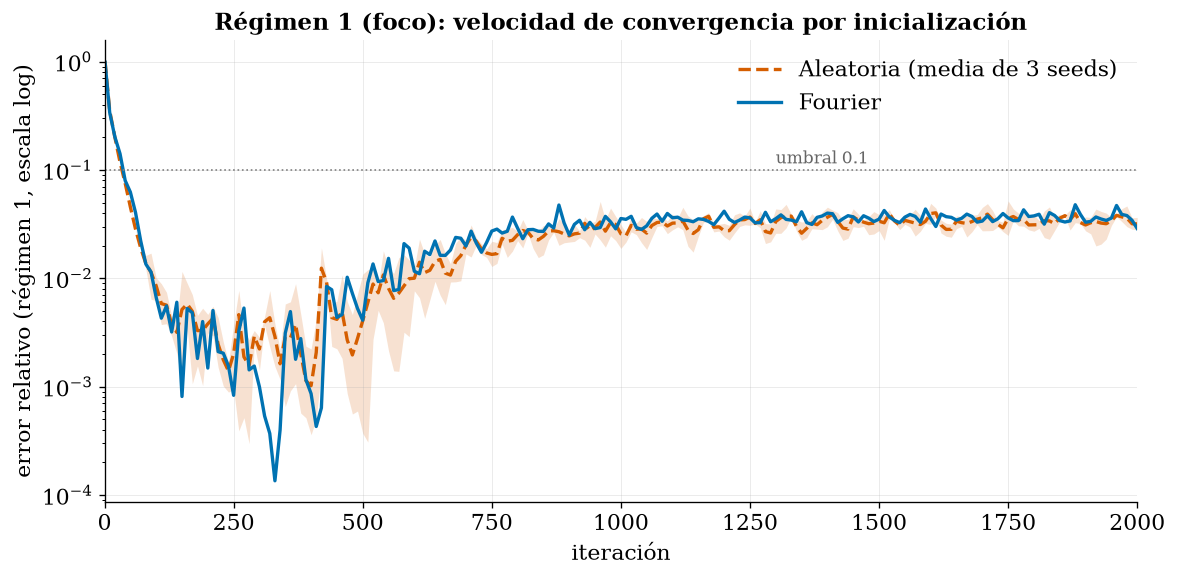

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
# error relativo del régimen 1 (columna 2)
lo1 = reh_r_stack[:, :, 2].min(0)
hi1 = reh_r_stack[:, :, 2].max(0)
ax.fill_between(rei_r, lo1, hi1, color=C_RANDOM, alpha=0.18, lw=0)
ax.plot(rei_r, reh_r_stack[:, :, 2].mean(0), color=C_RANDOM, ls=LS_RANDOM, lw=2,
        label="Aleatoria (media de 3 seeds)")
ax.plot(rei_f, reh_f[:, 2], color=C_FOURIER, ls=LS_FOURIER, lw=2, label="Fourier")

ax.axhline(0.1, color="0.5", lw=1, ls=":")
ax.text(rei_f[-1]*0.65, 0.115, "umbral 0.1", color="0.4", fontsize=10)
ax.set_yscale("log")
ax.set_xlim(0, ITERS)
ax.set_xlabel("iteración")
ax.set_ylabel("error relativo (régimen 1, escala log)")
ax.set_title("Régimen 1 (foco): velocidad de convergencia por inicialización",
             fontweight="bold")
ax.legend()
plt.show()

---

## 5 · Compresión: ¿cuánta señal vive en pocos coeficientes?

Usamos los $2K=50$ coeficientes de la capa de Fourier, $c = W_1 x$. Ordenamos por
magnitud, conservamos los $m$ mayores y reconstruimos por **síntesis**
$x \approx \text{W1}^{\text{(sin escala)}}\!{}^\top (c \odot \text{máscara})$.
Medimos el error relativo vs $m$ y contamos cuántos coeficientes bastan para
capturar el **95 % de la energía**.

In [20]:
# Base sin la escala 2/N, para la síntesis de reconstrucción
def base_fourier_sin_escala(t, K):
    ks = np.arange(1, K + 1)
    ang = 2 * np.pi * np.outer(ks, t)
    BASE = np.empty((2 * K, N))
    BASE[0::2] = np.cos(ang)
    BASE[1::2] = np.sin(ang)
    return BASE

BASE = base_fourier_sin_escala(t, K)

def curva_compresion(x):
    """Curva de compresión para una señal: error relativo y energía acumulada
    para cada número m de coeficientes conservados."""
    c = W1_fourier @ x
    orden = np.argsort(-np.abs(c))
    total = np.sum(x**2)
    errs = np.empty(2*K + 1)
    eners = np.empty(2*K + 1)
    errs[0] = 1.0
    eners[0] = 0.0
    for m in range(1, 2*K + 1):
        mask = np.zeros(2*K)
        mask[orden[:m]] = 1.0
        xr = BASE.T @ (c * mask)
        errs[m] = np.linalg.norm(xr - x) / np.linalg.norm(x)
        eners[m] = np.sum(xr**2) / total
    return errs, eners

E_err = np.stack([curva_compresion(X[i])[0] for i in range(len(X))])   # (24, 51)
E_ene = np.stack([curva_compresion(X[i])[1] for i in range(len(X))])

def coefs_95(ener):
    """Primer m con energía ≥ 0.95."""
    idx = np.where(ener >= 0.95)[0]
    return int(idx[0]) if len(idx) else 2*K

m95 = np.array([coefs_95(E_ene[i]) for i in range(len(X))])

print("Coeficientes necesarios para el 95 % de la energía (mediana por régimen):")
for r in REGIMENES:
    mr = m95[y==r]
    print(f"  {NOMBRE_REG[r]:36s} mediana {int(np.median(mr)):2d}  (rango {mr.min()}–{mr.max()})")
print(f"  {'GLOBAL':36s} mediana {int(np.median(m95)):2d}")

Coeficientes necesarios para el 95 % de la energía (mediana por régimen):
  Régimen 0 (μ=0, sin dispersión)      mediana  5  (rango 3–5)
  Régimen 1 (μ=5, intermedia)          mediana  8  (rango 4–11)
  Régimen 2 (μ=15, fuerte)             mediana  6  (rango 4–10)
  GLOBAL                               mediana  5


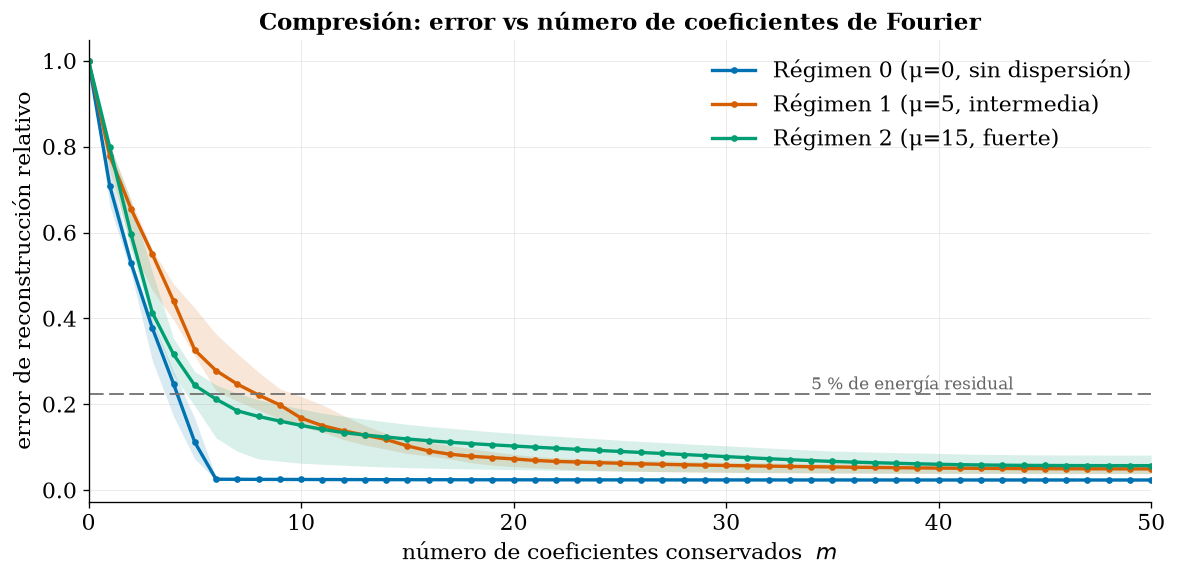

In [21]:
ms = np.arange(0, 2*K + 1)
fig, ax = plt.subplots(figsize=(10, 5))

for r in REGIMENES:
    med = np.median(E_err[y==r], axis=0)
    lo  = np.percentile(E_err[y==r], 25, axis=0)
    hi  = np.percentile(E_err[y==r], 75, axis=0)
    ax.fill_between(ms, lo, hi, color=C_REG[r], alpha=0.15, lw=0)
    ax.plot(ms, med, color=C_REG[r], lw=2, marker="o", ms=3, label=NOMBRE_REG[r])

ax.axhline(np.sqrt(0.05), color="0.45", lw=1.1, ls=(0, (8, 3)))
ax.text(2*K*0.68, np.sqrt(0.05)*1.05, "5 % de energía residual", color="0.4", fontsize=10)

ax.set_xlabel("número de coeficientes conservados  $m$")
ax.set_ylabel("error de reconstrucción relativo")
ax.set_title("Compresión: error vs número de coeficientes de Fourier",
             fontweight="bold")
ax.set_xlim(0, 2*K)
ax.legend()
plt.show()

---

## 6 · Conclusiones — ¿ayuda arrancar en la base de Fourier?

1. **En su arranque, la capa de Fourier *es* la Transformada de Fourier** — coincide
   con `np.fft` a precisión de máquina ($\sim 10^{-15}$). La energía media del
   dataset es **0.678**.

2. **Con $W_1$ entrenable, la calidad final es equivalente** (Sección 4): ambas
   inicializaciones cruzan el umbral de error relativo 0.1 con pocas iteraciones de
   diferencia y alcanzan errores finales del mismo orden. Con 50 características
   para 24 señales, una proyección aleatoria de igual escala funciona como un
   *reservorio* igual de expresivo.

3. **Sobre el régimen 1 (foco)** (Sección 4.3): la inicialización Fourier muestra una
   ventaja pequeña pero consistente en la velocidad temprana de convergencia. Esto
   es coherente con la física: el régimen 1 tiene dispersión intermedia ($\mu=5$),
   donde las frecuencias no caen exactamente en la rejilla pero tampoco están tan
   lejos como en el régimen 2.

4. **Compresión** (Sección 5): el régimen 0 es el más comprimible (las frecuencias
   enteras caen exactamente en la rejilla de Fourier); los regímenes 1 y 2
   necesitan más coeficientes por la fuga espectral. La base de Fourier es más
   eficiente como *representación* que como inicialización para la reconstrucción.

**Respuesta a la pregunta central:** arrancar en la base de Fourier no da una
ventaja decisiva en la calidad o velocidad de reconstrucción cuando $W_1$ se puede
entrenar —el descenso de gradiente compensa rápidamente la inicialización—. Sin
embargo, la base de Fourier sí es superior como *representación comprimible* de la
señal (pocos coeficientes capturan casi toda la energía), y eso es valioso cuando
se busca interpretar *qué* información contiene cada coeficiente.